# Selecting Top-k Configs from a Screening Sweep

Ranks `(feature_set, mining_setting, granularity)` configs from a
`run_screening_sweep.py` run using the logic in
`thesis.metrics.config_selection`:

1. **Mean LR score** (primary) -- mean of `SCORE_COL` across all evaluated
   windows, per config.
2. **Stability** -- std of that score across windows, used as a *penalty* on
   the ranking (`selection_score = score_mean - LAM * score_std`), not a
   standalone filter.
3. **Floor performance** -- a sanity check applied to the ranked shortlist
   (not baked into the ranking formula): flag any survivor whose worst (or
   10th-percentile) window falls below `FLOOR_THRESHOLD`.
4. **Feature parsimony** -- optional tie-breaker; configs whose
   `selection_score` is within `TIEBREAK_TOL` of each other are reordered by
   ascending feature count.

All thresholds are set in the config cell below -- the module itself takes
them as arguments and hardcodes nothing.

In [1]:
from __future__ import annotations

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from thesis.paths import ARTIFACTS_DIR
from thesis.metrics.config_selection import (
    summarize_configs,
    rank_configs,
    apply_floor_check,
    select_top_k,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Thresholds

Edit these and re-run below -- nothing past this cell needs to change.

In [2]:
SCENARIO = "cscas"
RUN_ID = None  # e.g. "20260708_043553"; None -> latest run dir for SCENARIO

# "precision" (TP/(TP+FP)) over "auc": with heavy class imbalance (few attacks),
# ROC AUC stays high even as absolute FP counts grow (FPR's TN-heavy denominator
# hides it), so it doesn't track the thing we actually care about -- alert
# fatigue from false positives. Keep an eye on `recall` too (e.g. via the floor
# check below) so this doesn't just reward configs that stopped flagging attacks.
SCORE_COL = "precision"
GROUP_COLS = ["feature_set", "mining_setting", "granularity", "model"]

LAM = 0.5  # selection_score = score_mean - LAM * score_std
K = 10  # shortlist size

FLOOR_COL = "score_min"  # or "score_p10" for a softer floor
# precision across windows in this run spans ~0.65-0.92 (mean ~0.80) -- unlike
# AUC this is NOT clustered near 1.0, so the floor needs to live in that range.
FLOOR_THRESHOLD = 0.6

TIEBREAK_COL = "n_features_mean"
TIEBREAK_TOL = 0.0  # >0 to prefer smaller schemas among near-tied configs

In [3]:
sweep_dir = ARTIFACTS_DIR / "experiments" / "screening_sweep" / SCENARIO

if RUN_ID:
    run_dir = sweep_dir / RUN_ID
else:
    run_dirs = [p for p in sweep_dir.iterdir() if p.is_dir()]
    run_dir = sorted(run_dirs)[-1]

per_window = pd.read_csv(run_dir / "per_window_results.csv")
print(f"Loaded {len(per_window)} rows from {run_dir}")
per_window.head()

Loaded 205 rows from /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/screening_sweep/cscas/20260709_020952


,scenario,granularity,window_id,win_start_frac,win_end_frac,n_alert_groups,n_attack,n_train,n_test,feature_set,mining_setting,model,n_features,auc,f1,accuracy,precision,recall,tp,fp,tn,fn,single_class_split,mining_cache_hit
0,cscas,0.1,0,0.0,0.1,139532,1765,97672,41860,baseline,NaN,logreg,41,0.998034,0.717017,0.992929,0.569909,0.966495,375,283,41189,13,False,NaN
1,cscas,0.1,0,0.0,0.1,139532,1765,97672,41860,symbolic,gr3.0_md3,logreg,331,0.983405,0.806034,0.995700,0.692593,0.963918,374,166,41306,14,False,True
2,cscas,0.1,0,0.0,0.1,139532,1765,97672,41860,symbolic,gr3.0_md4,logreg,332,0.983613,0.853575,0.996918,0.762677,0.969072,376,117,41355,12,False,False
3,cscas,0.1,0,0.0,0.1,139532,1765,97672,41860,symbolic,gr3.0_md5,logreg,334,0.939744,0.844907,0.996799,0.766807,0.940722,365,111,41361,23,False,False
4,cscas,0.1,0,0.0,0.1,139532,1765,97672,41860,symbolic,gr4.0_md3,logreg,313,0.983434,0.811159,0.995796,0.694853,0.974227,378,166,41306,10,False,False


## 1. Summarize + rank

In [4]:
summary = summarize_configs(
    per_window, score_col=SCORE_COL, group_cols=GROUP_COLS
)
ranked = rank_configs(
    summary,
    lam=LAM,
    tiebreak_col=TIEBREAK_COL,
    tiebreak_tol=TIEBREAK_TOL,
)
ranked.head(15)

,feature_set,mining_setting,granularity,model,score_mean,score_std,score_min,score_max,n_windows,score_cv,score_p10,n_features_mean,selection_score
0,symbolic,gr5.0_md5,0.1,logreg,0.850673,0.056168,0.766807,0.916919,10,0.066027,0.777111,299.000000,0.822590
1,symbolic,gr4.0_md5,0.1,logreg,0.850673,0.056168,0.766807,0.916919,10,0.066027,0.777111,337.400000,0.822590
2,symbolic,gr3.0_md5,0.1,logreg,0.850571,0.056252,0.766807,0.916919,10,0.066134,0.777111,376.600000,0.822445
3,symbolic,gr3.0_md5,0.2,logreg,0.836168,0.046134,0.801265,0.888471,3,0.055173,0.804765,380.666667,0.813101
4,symbolic,gr4.0_md5,0.2,logreg,0.824711,0.039483,0.789836,0.891263,5,0.047875,0.794408,347.800000,0.804969
5,symbolic,gr5.0_md5,0.2,logreg,0.824562,0.039288,0.789655,0.890704,5,0.047647,0.794299,280.400000,0.804918
6,symbolic,gr4.0_md4,0.1,logreg,0.836010,0.065864,0.756681,0.916667,10,0.078784,0.760252,336.100000,0.803078
7,symbolic,gr3.0_md4,0.1,logreg,0.835875,0.065828,0.756681,0.916667,10,0.078753,0.762078,375.300000,0.802961
8,symbolic,gr5.0_md4,0.1,logreg,0.835351,0.066549,0.755556,0.916667,10,0.079666,0.756568,297.700000,0.802076
9,symbolic,gr3.0_md5,0.5,logreg,0.804532,0.010449,0.797143,0.811921,2,0.012988,0.798621,348.000000,0.799307


## 2. Top-k shortlist + floor check

In [5]:
shortlist = select_top_k(ranked, k=K)
shortlist = apply_floor_check(
    shortlist, floor_threshold=FLOOR_THRESHOLD, floor_col=FLOOR_COL
)

n_failing = (~shortlist["passes_floor"]).sum()
if n_failing:
    print(
        f"{n_failing}/{K} shortlisted configs fail the floor check "
        f"({FLOOR_COL} < {FLOOR_THRESHOLD}) despite a strong mean -- "
        "inspect below before finalizing."
    )
else:
    print(f"All {K} shortlisted configs clear the floor check.")

shortlist

All 10 shortlisted configs clear the floor check.


,feature_set,mining_setting,granularity,model,score_mean,score_std,score_min,score_max,n_windows,score_cv,score_p10,n_features_mean,selection_score,passes_floor
0,symbolic,gr5.0_md5,0.1,logreg,0.850673,0.056168,0.766807,0.916919,10,0.066027,0.777111,299.000000,0.822590,True
1,symbolic,gr4.0_md5,0.1,logreg,0.850673,0.056168,0.766807,0.916919,10,0.066027,0.777111,337.400000,0.822590,True
2,symbolic,gr3.0_md5,0.1,logreg,0.850571,0.056252,0.766807,0.916919,10,0.066134,0.777111,376.600000,0.822445,True
3,symbolic,gr3.0_md5,0.2,logreg,0.836168,0.046134,0.801265,0.888471,3,0.055173,0.804765,380.666667,0.813101,True
4,symbolic,gr4.0_md5,0.2,logreg,0.824711,0.039483,0.789836,0.891263,5,0.047875,0.794408,347.800000,0.804969,True
5,symbolic,gr5.0_md5,0.2,logreg,0.824562,0.039288,0.789655,0.890704,5,0.047647,0.794299,280.400000,0.804918,True
6,symbolic,gr4.0_md4,0.1,logreg,0.836010,0.065864,0.756681,0.916667,10,0.078784,0.760252,336.100000,0.803078,True
7,symbolic,gr3.0_md4,0.1,logreg,0.835875,0.065828,0.756681,0.916667,10,0.078753,0.762078,375.300000,0.802961,True
8,symbolic,gr5.0_md4,0.1,logreg,0.835351,0.066549,0.755556,0.916667,10,0.079666,0.756568,297.700000,0.802076,True
9,symbolic,gr3.0_md5,0.5,logreg,0.804532,0.010449,0.797143,0.811921,2,0.012988,0.798621,348.000000,0.799307,True


## 3. Save shortlist for Experiment 2

Writes the standard shortlist file format `thesis.metrics.shortlist.load_shortlist`
expects (`feature_set,mining_setting,granularity,model` columns -- extra columns
like `score_mean` are allowed but not required, so this is just the shortlist
DataFrame trimmed to those 4). Hand-edit the saved CSV afterward to add/drop rows
if you want to override the automatic top-k selection.

In [6]:
SHORTLIST_PATH = sweep_dir / "shortlist.csv"

shortlist_out = shortlist[["feature_set", "mining_setting", "granularity", "model"]]
shortlist_out.to_csv(SHORTLIST_PATH, index=False)
print(f"Saved shortlist ({len(shortlist_out)} configs) → {SHORTLIST_PATH}")
shortlist_out

Saved shortlist (10 configs) → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/screening_sweep/cscas/shortlist.csv


,feature_set,mining_setting,granularity,model
0,symbolic,gr5.0_md5,0.1,logreg
1,symbolic,gr4.0_md5,0.1,logreg
2,symbolic,gr3.0_md5,0.1,logreg
3,symbolic,gr3.0_md5,0.2,logreg
4,symbolic,gr4.0_md5,0.2,logreg
5,symbolic,gr5.0_md5,0.2,logreg
6,symbolic,gr4.0_md4,0.1,logreg
7,symbolic,gr3.0_md4,0.1,logreg
8,symbolic,gr5.0_md4,0.1,logreg
9,symbolic,gr3.0_md5,0.5,logreg


## 4. Visualize: mean ± std, floor threshold, shortlist cutoff

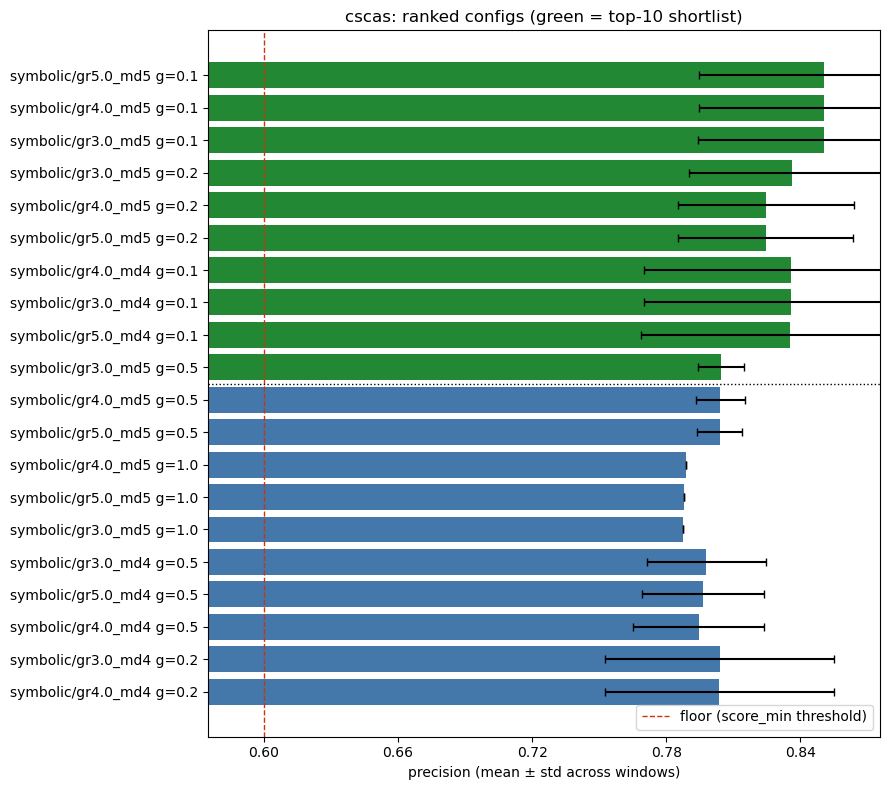

In [7]:
PLOT_TOP_N = 20  # how far down the full ranking to show

plot_df = ranked.head(PLOT_TOP_N).copy()
plot_df["label"] = (
    plot_df["feature_set"].astype(str)
    + "/"
    + plot_df["mining_setting"].astype(str)
    + " g="
    + plot_df["granularity"].astype(str)
)

SHORTLISTED_COLOR = "#228833"
OTHER_COLOR = "#4477AA"
FLOOR_LINE_COLOR = "#CC3311"

colors = [
    SHORTLISTED_COLOR if i < K else OTHER_COLOR for i in range(len(plot_df))
]

fig, ax = plt.subplots(figsize=(9, 0.35 * len(plot_df) + 1))
ax.barh(
    plot_df["label"],
    plot_df["score_mean"],
    xerr=plot_df["score_std"],
    color=colors,
    capsize=3,
)
ax.axvline(FLOOR_THRESHOLD, color=FLOOR_LINE_COLOR, linestyle="--", linewidth=1, label=f"floor ({FLOOR_COL} threshold)")
ax.axhline(len(plot_df) - K - 0.5, color="black", linestyle=":", linewidth=1)
ax.invert_yaxis()
ax.set_xlabel(f"{SCORE_COL} (mean ± std across windows)")
ax.set_title(f"{SCENARIO}: ranked configs (green = top-{K} shortlist)")
ax.legend(loc="lower right")
ax.xaxis.set_major_locator(mticker.MaxNLocator(6))

# Scores here typically live in a narrow band near 1.0 -- zoom the x-axis to
# that band (rather than the full [0, 1] range) so the mean/std differences
# that actually drive the ranking are visible.
x_lo = min((plot_df["score_mean"] - plot_df["score_std"]).min(), FLOOR_THRESHOLD)
x_hi = plot_df["score_mean"].max()
margin = (x_hi - x_lo) * 0.1 or 0.001
ax.set_xlim(x_lo - margin, x_hi + margin)
fig.tight_layout()

## 5. Recall for the same ranked configs

Same configs, same order, same top-`K` highlighting as the plot above --
`recall` in place of `SCORE_COL` (precision), so a config that ranks well on
precision but is quietly missing attacks stands out.

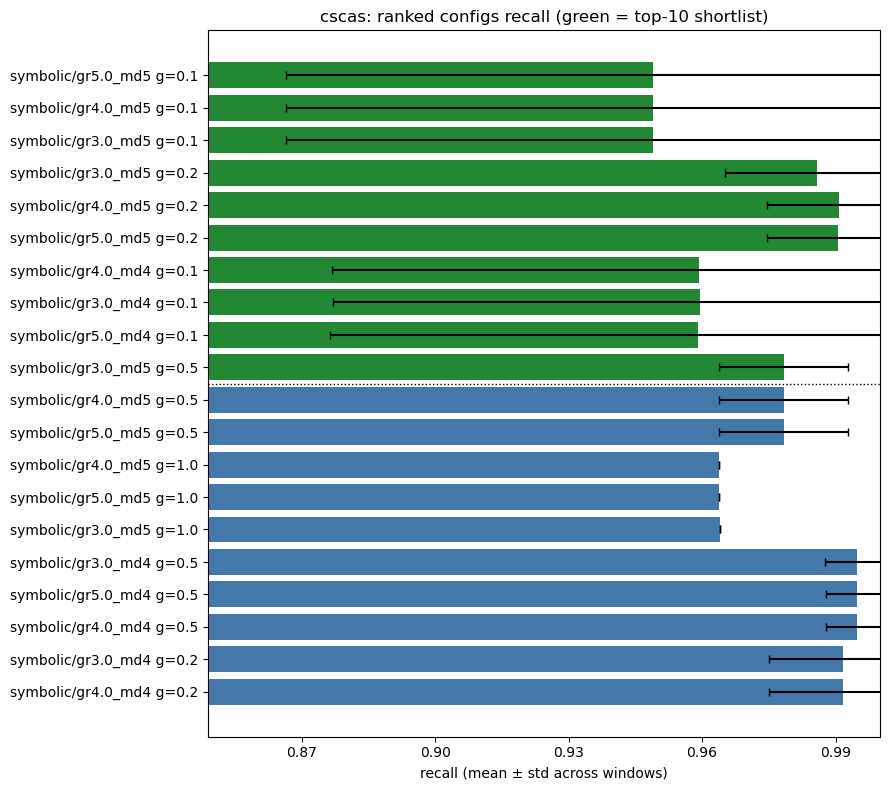

In [8]:
recall_summary = summarize_configs(
    per_window, score_col="recall", group_cols=GROUP_COLS
).rename(columns={"score_mean": "recall_mean", "score_std": "recall_std"})

recall_plot_df = plot_df[[*GROUP_COLS, "label"]].merge(
    recall_summary[[*GROUP_COLS, "recall_mean", "recall_std"]],
    on=GROUP_COLS,
    how="left",
)

fig, ax = plt.subplots(figsize=(9, 0.35 * len(recall_plot_df) + 1))
ax.barh(
    recall_plot_df["label"],
    recall_plot_df["recall_mean"],
    xerr=recall_plot_df["recall_std"],
    color=colors,
    capsize=3,
)
ax.axhline(len(recall_plot_df) - K - 0.5, color="black", linestyle=":", linewidth=1)
ax.invert_yaxis()
ax.set_xlabel("recall (mean ± std across windows)")
ax.set_title(f"{SCENARIO}: ranked configs recall (green = top-{K} shortlist)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(6))

x_lo = (recall_plot_df["recall_mean"] - recall_plot_df["recall_std"]).min()
x_hi = (recall_plot_df["recall_mean"] + recall_plot_df["recall_std"]).max()
margin = (x_hi - x_lo) * 0.1 or 0.001
ax.set_xlim(max(x_lo - margin, 0.0), min(x_hi + margin, 1.0))
fig.tight_layout()

## 6. Symbolic vs. baseline comparison

Every screening-sweep window has a `feature_set="baseline"` row (no symbolic
features) alongside each `feature_set="symbolic"` row, evaluated on the exact
same train/test split. `thesis.metrics.baseline_comparison.pair_with_baseline`
joins each symbolic row to its baseline row from that same
(granularity, window_id, model), then `summarize_comparison` averages the
per-window deltas into one row per symbolic config:

- `auc_delta`, `precision_delta`, `recall_delta` -- symbolic minus baseline.
- `fp_reduction` -- baseline FP count minus symbolic FP count (positive =
  symbolic raised fewer false alarms).
- `fn_increase` -- symbolic FN count minus baseline FN count (positive =
  symbolic missed more attacks than baseline on that window; the cost side of
  any FP reduction).

Restricted to the same top-`PLOT_TOP_N` symbolic configs as the ranking plot
above, in the same order, with a `shortlisted` flag for the top-`K` configs.

In [9]:
from thesis.metrics.baseline_comparison import pair_with_baseline, summarize_comparison

paired = pair_with_baseline(per_window)
comparison = summarize_comparison(paired)

# Same configs/order as plot_df (section 4), restricted to symbolic rows --
# a baseline config has no baseline to compare itself against.
compare_table = plot_df[plot_df["feature_set"] == "symbolic"][
    [*GROUP_COLS, "label", "score_mean"]
].merge(comparison, on=["mining_setting", "granularity", "model"], how="left")

shortlist_keys = set(
    zip(
        shortlist["feature_set"],
        shortlist["mining_setting"],
        shortlist["granularity"],
        shortlist["model"],
    )
)
compare_table["shortlisted"] = [
    (fs, ms, g, m) in shortlist_keys
    for fs, ms, g, m in zip(
        compare_table["feature_set"],
        compare_table["mining_setting"],
        compare_table["granularity"],
        compare_table["model"],
    )
]

compare_table

,feature_set,mining_setting,granularity,model,label,score_mean,n_windows,auc_delta_mean,precision_delta_mean,recall_delta_mean,fp_reduction_mean,fp_reduction_pct_mean,fn_increase_mean,shortlisted
0,symbolic,gr5.0_md5,0.1,logreg,symbolic/gr5.0_md5 g=0.1,0.850673,10,-0.009199,0.141778,-0.034281,163.500000,0.567694,26.600000,True
1,symbolic,gr4.0_md5,0.1,logreg,symbolic/gr4.0_md5 g=0.1,0.850673,10,-0.009199,0.141778,-0.034281,163.500000,0.567694,26.600000,True
2,symbolic,gr3.0_md5,0.1,logreg,symbolic/gr3.0_md5 g=0.1,0.850571,10,-0.009198,0.141676,-0.034281,163.400000,0.567299,26.600000,True
3,symbolic,gr3.0_md5,0.2,logreg,symbolic/gr3.0_md5 g=0.2,0.836168,3,-0.000698,0.147895,-0.013788,307.666667,0.572920,19.666667,True
4,symbolic,gr4.0_md5,0.2,logreg,symbolic/gr4.0_md5 g=0.2,0.824711,5,-0.000479,0.142841,-0.006001,317.000000,0.537121,8.600000,True
5,symbolic,gr5.0_md5,0.2,logreg,symbolic/gr5.0_md5 g=0.2,0.824562,5,-0.000434,0.142693,-0.006218,316.800000,0.536787,8.800000,True
6,symbolic,gr4.0_md4,0.1,logreg,symbolic/gr4.0_md4 g=0.1,0.836010,10,-0.004918,0.127115,-0.023933,150.000000,0.509848,21.700000,True
7,symbolic,gr3.0_md4,0.1,logreg,symbolic/gr3.0_md4 g=0.1,0.835875,10,-0.005030,0.126980,-0.023675,149.700000,0.508805,21.600000,True
8,symbolic,gr5.0_md4,0.1,logreg,symbolic/gr5.0_md4 g=0.1,0.835351,10,-0.004883,0.126456,-0.024191,149.500000,0.508182,21.800000,True
9,symbolic,gr3.0_md5,0.5,logreg,symbolic/gr3.0_md5 g=0.5,0.804532,2,-0.015634,0.083858,-0.011475,556.000000,0.378211,35.500000,True


## 7. Visualize: AUC / FP reduction / FN increase vs. baseline

Same configs, order, and shortlist coloring as the plots above. Positive
`fp_reduction` (fewer false alarms) is the payoff; positive `fn_increase`
(more missed attacks) is the cost -- read the two side by side, not just the
AUC delta, since AUC can look flat while precision-driving FP counts move a
lot (see `SCORE_COL`'s rationale in the thresholds cell).

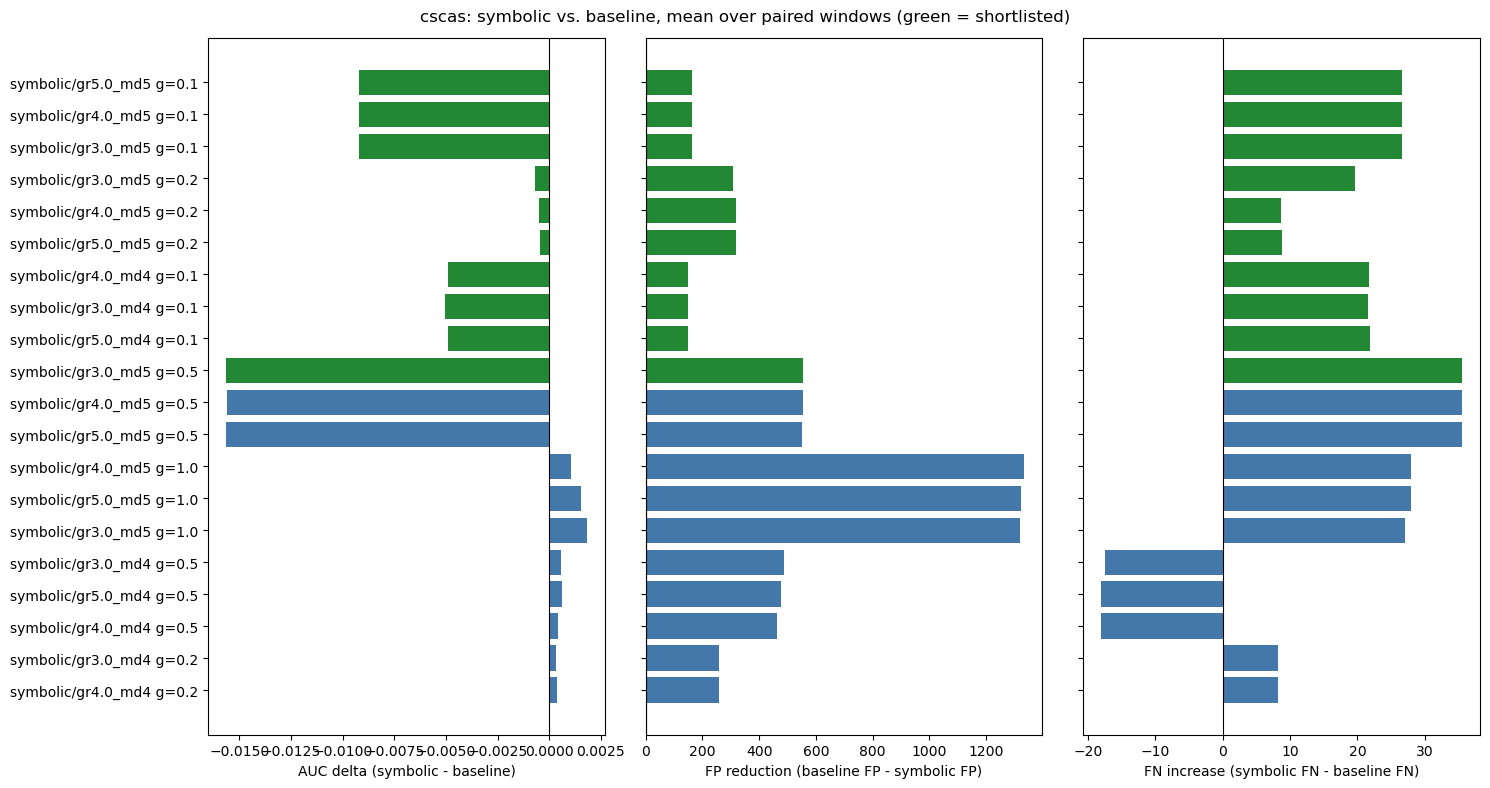

In [10]:
plot_compare = compare_table.dropna(subset=["auc_delta_mean"]).reset_index(drop=True)
compare_colors = [
    SHORTLISTED_COLOR if s else OTHER_COLOR for s in plot_compare["shortlisted"]
]

fig, axes = plt.subplots(
    1, 3, figsize=(15, 0.35 * len(plot_compare) + 1), sharey=True
)

axes[0].barh(plot_compare["label"], plot_compare["auc_delta_mean"], color=compare_colors)
axes[0].set_xlabel("AUC delta (symbolic - baseline)")

axes[1].barh(
    plot_compare["label"], plot_compare["fp_reduction_mean"], color=compare_colors
)
axes[1].set_xlabel("FP reduction (baseline FP - symbolic FP)")

axes[2].barh(
    plot_compare["label"], plot_compare["fn_increase_mean"], color=compare_colors
)
axes[2].set_xlabel("FN increase (symbolic FN - baseline FN)")

for ax in axes:
    ax.axvline(0, color="black", linewidth=0.8)
axes[0].invert_yaxis()  # shared y-axis: inverting one flips all three
fig.suptitle(f"{SCENARIO}: symbolic vs. baseline, mean over paired windows (green = shortlisted)")
fig.tight_layout()

## 8. Parameter importance: which knobs matter?

Everything above picks *a* shortlist. This section is the evidence for
fixing some of the sweep's axes and only varying the rest in Experiments
2-4: for each candidate parameter -- `feature_set`, the mining-setting's two
sub-thresholds (`min_growth_rate`, `max_depth`), `granularity`, `model` --
`thesis.metrics.sensitivity.parameter_importance` runs a one-way ANOVA of
`score_mean` (from `summary`, section 1) against that parameter's levels,
marginalized over every other parameter.

`mining_setting` is expanded into `min_growth_rate` / `max_depth` first --
a table over the bundled categorical could only ever say "mining_setting
matters", not which of its two axes is doing the work.

Read `eta_squared` (SS_between / SS_total) as the headline number: it's
0-1 and comparable across parameters regardless of how many levels each
has, unlike the raw F-statistic. `effect_range` is the same idea in
`SCORE_COL`'s own units -- how far apart the best and worst level's mean
scores are. `p_value` is a one-way ANOVA significance test over
config-level means (not independent per-window samples), so read it as
"is this marginal effect distinguishable from noise across the configs we
ran", not a population-level claim -- see the function's docstring.

`model` has a single level in this run (`logreg` -- SVM was ruled out
separately for being too slow at these window sizes, not by this
analysis), so it comes back `n_levels=1` / `NaN` stats: "not screened
here" is the correct reading, not "unimportant".

In [11]:
from thesis.metrics.sensitivity import expand_mining_setting, main_effects, parameter_importance

# eta_squared at/above this -> "moves the score enough to keep varying it in
# Experiments 2-4"; below it (or not screened, e.g. model) -> candidate to
# fix at the shortlist's winning level. 0.05 is a conventional small-effect
# cutoff (Cohen), not derived from this data -- revisit if the ranking looks
# borderline.
IMPORTANT_ETA_THRESHOLD = 0.05

PARAM_COLS = ["feature_set", "min_growth_rate", "max_depth", "granularity", "model"]

summary_expanded = expand_mining_setting(summary)
importance = parameter_importance(summary_expanded, score_col="score_mean", param_cols=PARAM_COLS)
importance

,parameter,n_levels,n_configs,eta_squared,f_stat,p_value,effect_range
0,feature_set,2,50,0.383515,29.860779,0.000002,0.098133
1,granularity,5,50,0.380292,6.903721,0.000202,0.078852
2,max_depth,3,45,0.305755,9.248707,0.000470,0.052130
3,min_growth_rate,3,45,0.000236,0.004959,0.995054,0.001419
4,model,1,50,NaN,NaN,NaN,NaN


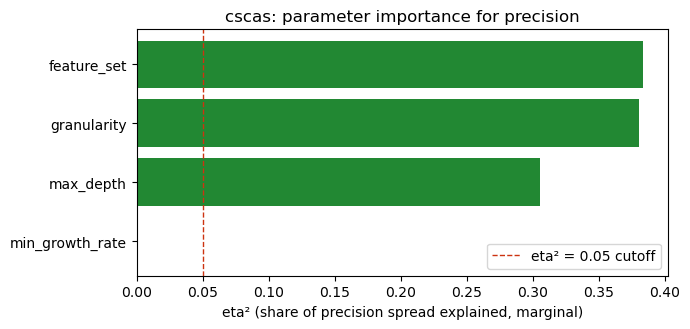

In [12]:
IMPORTANT_COLOR = "#228833"
FIXED_COLOR = "#BBBBBB"

plot_importance = importance.dropna(subset=["eta_squared"]).sort_values("eta_squared")
bar_colors = [
    IMPORTANT_COLOR if v >= IMPORTANT_ETA_THRESHOLD else FIXED_COLOR
    for v in plot_importance["eta_squared"]
]

fig, ax = plt.subplots(figsize=(7, 0.6 * len(plot_importance) + 1))
ax.barh(plot_importance["parameter"], plot_importance["eta_squared"], color=bar_colors)
ax.axvline(
    IMPORTANT_ETA_THRESHOLD,
    color=FLOOR_LINE_COLOR,
    linestyle="--",
    linewidth=1,
    label=f"eta² = {IMPORTANT_ETA_THRESHOLD} cutoff",
)
ax.set_xlabel(f"eta² (share of {SCORE_COL} spread explained, marginal)")
ax.set_title(f"{SCENARIO}: parameter importance for {SCORE_COL}")
ax.legend(loc="lower right")
fig.tight_layout()

### Main effects

Same grouping as the eta² table, laid out per-parameter instead of
collapsed to one number: mean ± std of `score_mean` at each level, marginalized
over every other parameter. A parameter with a high eta² should visibly
separate its bars here; a low-eta² parameter's bars should look flat within
noise -- this is the plot to put next to the eta² table when defending "we
fixed X" in the thesis.

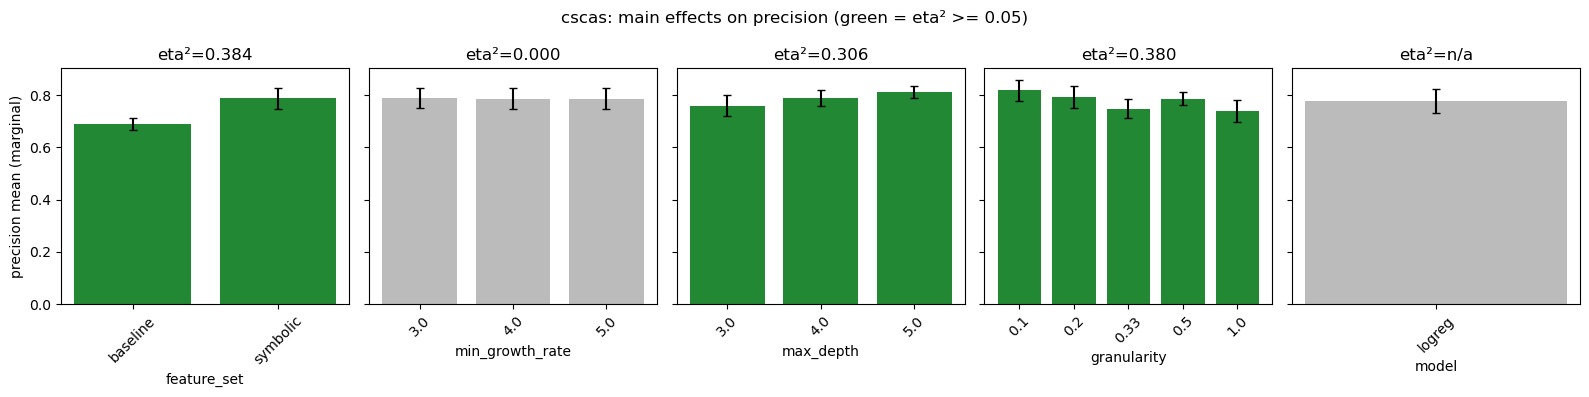

In [13]:
effects = main_effects(summary_expanded, score_col="score_mean", param_cols=PARAM_COLS)

params_with_data = [p for p in PARAM_COLS if p in effects["parameter"].unique()]
n_params = len(params_with_data)
fig, axes = plt.subplots(1, n_params, figsize=(3.2 * n_params, 4), sharey=True)
if n_params == 1:
    axes = [axes]

for ax, param in zip(axes, params_with_data):
    group = effects[effects["parameter"] == param].sort_values("level")
    eta_sq = importance.loc[importance["parameter"] == param, "eta_squared"].iloc[0]
    color = IMPORTANT_COLOR if pd.notna(eta_sq) and eta_sq >= IMPORTANT_ETA_THRESHOLD else FIXED_COLOR
    ax.bar(group["level"].astype(str), group["mean"], yerr=group["std"], capsize=3, color=color)
    ax.set_xlabel(param)
    eta_label = f"{eta_sq:.3f}" if pd.notna(eta_sq) else "n/a"
    ax.set_title(f"eta²={eta_label}")
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel(f"{SCORE_COL} mean (marginal)")
fig.suptitle(f"{SCENARIO}: main effects on {SCORE_COL} (green = eta² >= {IMPORTANT_ETA_THRESHOLD})")
fig.tight_layout()

### Recommendation: vary vs. fix

Splits `PARAM_COLS` by `IMPORTANT_ETA_THRESHOLD` and, for each parameter to
fix, reports the level the top-`K` shortlist (section 2) actually converged
on -- the concrete value to write into Experiments 2-4's config, not just
"fix this axis".

In [14]:
shortlist_expanded = expand_mining_setting(shortlist)

vary = importance.loc[importance["eta_squared"] >= IMPORTANT_ETA_THRESHOLD, "parameter"].tolist()
not_screened = importance.loc[importance["eta_squared"].isna(), "parameter"].tolist()
fix = importance.loc[
    importance["eta_squared"].notna() & (importance["eta_squared"] < IMPORTANT_ETA_THRESHOLD),
    "parameter",
].tolist()

print(f"Vary in Experiments 2-4 (eta² >= {IMPORTANT_ETA_THRESHOLD}):")
for p in vary:
    row = importance.loc[importance["parameter"] == p].iloc[0]
    print(f"  {p}: eta²={row['eta_squared']:.3f}, p={row['p_value']:.2g}, effect_range={row['effect_range']:.3f}")

print(f"\nFix at the shortlist's winning level (eta² < {IMPORTANT_ETA_THRESHOLD}):")
for p in fix:
    winning = shortlist_expanded[p].mode().tolist() if p in shortlist_expanded.columns else "?"
    print(f"  {p}: fix at {winning}")

if not_screened:
    print(f"\nNot screened here (single level in this sweep): {not_screened}")
    print("  -- e.g. model=logreg; see prior rationale for excluding alternatives before treating as fixed.")

Vary in Experiments 2-4 (eta² >= 0.05):
  feature_set: eta²=0.384, p=1.6e-06, effect_range=0.098
  granularity: eta²=0.380, p=0.0002, effect_range=0.079
  max_depth: eta²=0.306, p=0.00047, effect_range=0.052

Fix at the shortlist's winning level (eta² < 0.05):
  min_growth_rate: fix at [3.0]

Not screened here (single level in this sweep): ['model']
  -- e.g. model=logreg; see prior rationale for excluding alternatives before treating as fixed.
